In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from factor_analyzer import FactorAnalyzer # Perform statistical tests before PCA 
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("bank_marketing_part1_Data.csv")

In [3]:
df.head()

,spending,advance_payments,probability_of_full_payment,current_balance,credit_limit,min_payment_amt,max_spent_in_single_shopping
0,19.94,16.92,0.8752,6.675,3.763,3.252,6.550
1,15.99,14.89,0.9064,5.363,3.582,3.336,5.144
2,18.95,16.42,0.8829,6.248,3.755,3.368,6.148
3,10.83,12.96,0.8099,5.278,2.641,5.182,5.185
4,17.99,15.86,0.8992,5.890,3.694,2.068,5.837


In [4]:
df.isnull().sum()

spending                        0
advance_payments                0
probability_of_full_payment     0
current_balance                 0
credit_limit                    0
min_payment_amt                 0
max_spent_in_single_shopping    0
dtype: int64

In [5]:
df.describe(include="all")

,spending,advance_payments,probability_of_full_payment,current_balance,credit_limit,min_payment_amt,max_spent_in_single_shopping
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000


In [6]:
def univariateAnalysis_numeric(column):
    print("Description of " + column)
    print("----------------------------------------------------------------------------")
    print(df[column].describe(),end=' ')
    
    
    plt.figure()
    print("Distribution of " + column)
    print("----------------------------------------------------------------------------")
    sns.distplot(df[column], kde=False, color='g');
    plt.show()
    
    plt.figure()
    print("BoxPlot of " + column)
    print("----------------------------------------------------------------------------")
    ax = sns.boxplot(x=df[column])
    plt.show()

In [7]:
lstnumericcolumns=df.columns

Description of spending
----------------------------------------------------------------------------
count    210.000000
mean      14.847524
std        2.909699
min       10.590000
25%       12.270000
50%       14.355000
75%       17.305000
max       21.180000
Name: spending, dtype: float64 Distribution of spending
----------------------------------------------------------------------------


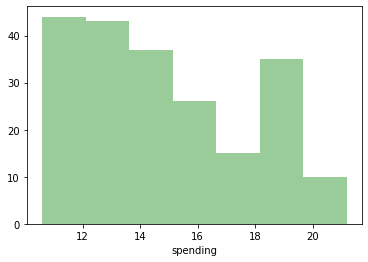

BoxPlot of spending
----------------------------------------------------------------------------


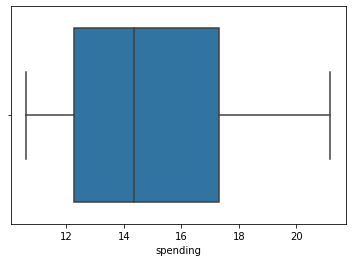

Description of advance_payments
----------------------------------------------------------------------------
count    210.000000
mean      14.559286
std        1.305959
min       12.410000
25%       13.450000
50%       14.320000
75%       15.715000
max       17.250000
Name: advance_payments, dtype: float64 Distribution of advance_payments
----------------------------------------------------------------------------


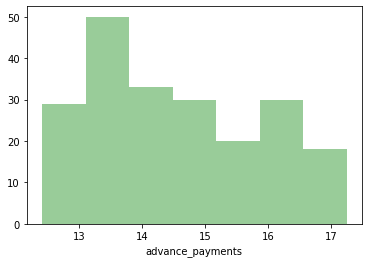

BoxPlot of advance_payments
----------------------------------------------------------------------------


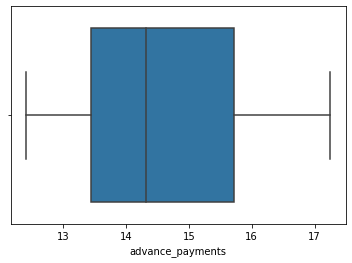

Description of probability_of_full_payment
----------------------------------------------------------------------------
count    210.000000
mean       0.870999
std        0.023629
min        0.808100
25%        0.856900
50%        0.873450
75%        0.887775
max        0.918300
Name: probability_of_full_payment, dtype: float64 Distribution of probability_of_full_payment
----------------------------------------------------------------------------


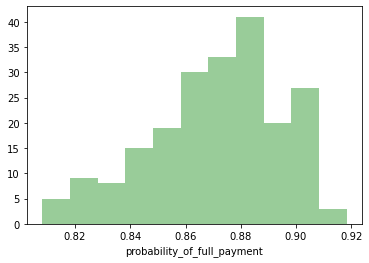

BoxPlot of probability_of_full_payment
----------------------------------------------------------------------------


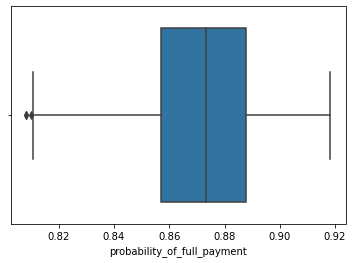

Description of current_balance
----------------------------------------------------------------------------
count    210.000000
mean       5.628533
std        0.443063
min        4.899000
25%        5.262250
50%        5.523500
75%        5.979750
max        6.675000
Name: current_balance, dtype: float64 Distribution of current_balance
----------------------------------------------------------------------------


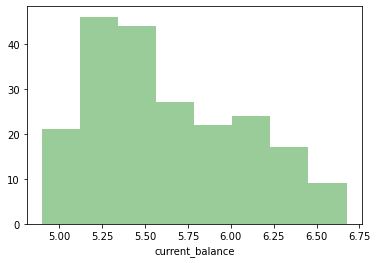

BoxPlot of current_balance
----------------------------------------------------------------------------


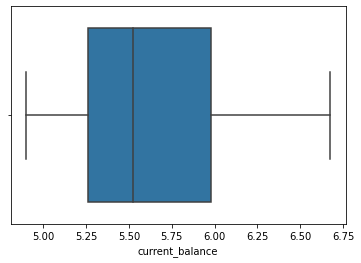

Description of credit_limit
----------------------------------------------------------------------------
count    210.000000
mean       3.258605
std        0.377714
min        2.630000
25%        2.944000
50%        3.237000
75%        3.561750
max        4.033000
Name: credit_limit, dtype: float64 Distribution of credit_limit
----------------------------------------------------------------------------


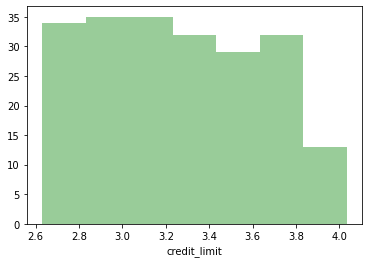

BoxPlot of credit_limit
----------------------------------------------------------------------------


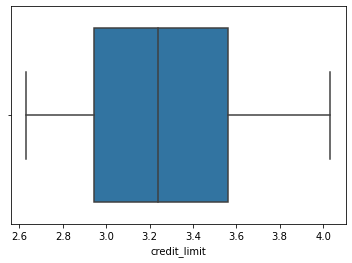

Description of min_payment_amt
----------------------------------------------------------------------------
count    210.000000
mean       3.700201
std        1.503557
min        0.765100
25%        2.561500
50%        3.599000
75%        4.768750
max        8.456000
Name: min_payment_amt, dtype: float64 Distribution of min_payment_amt
----------------------------------------------------------------------------


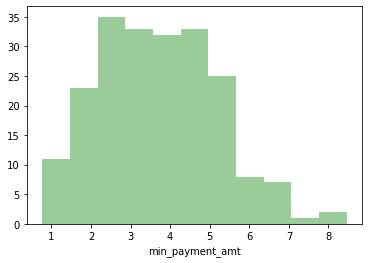

BoxPlot of min_payment_amt
----------------------------------------------------------------------------


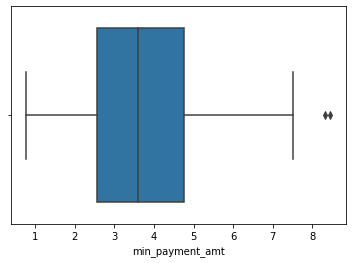

Description of max_spent_in_single_shopping
----------------------------------------------------------------------------
count    210.000000
mean       5.408071
std        0.491480
min        4.519000
25%        5.045000
50%        5.223000
75%        5.877000
max        6.550000
Name: max_spent_in_single_shopping, dtype: float64 Distribution of max_spent_in_single_shopping
----------------------------------------------------------------------------


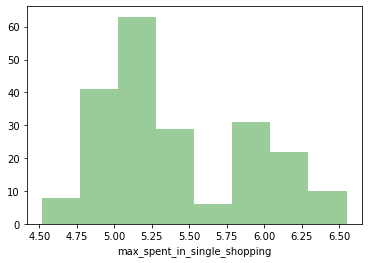

BoxPlot of max_spent_in_single_shopping
----------------------------------------------------------------------------


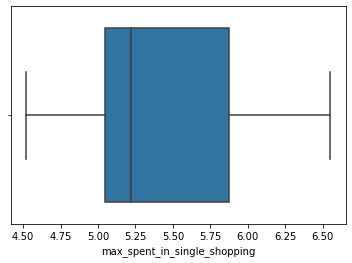

In [8]:
for x in lstnumericcolumns:
    univariateAnalysis_numeric(x)

In [9]:
corr = df.corr(method='pearson')

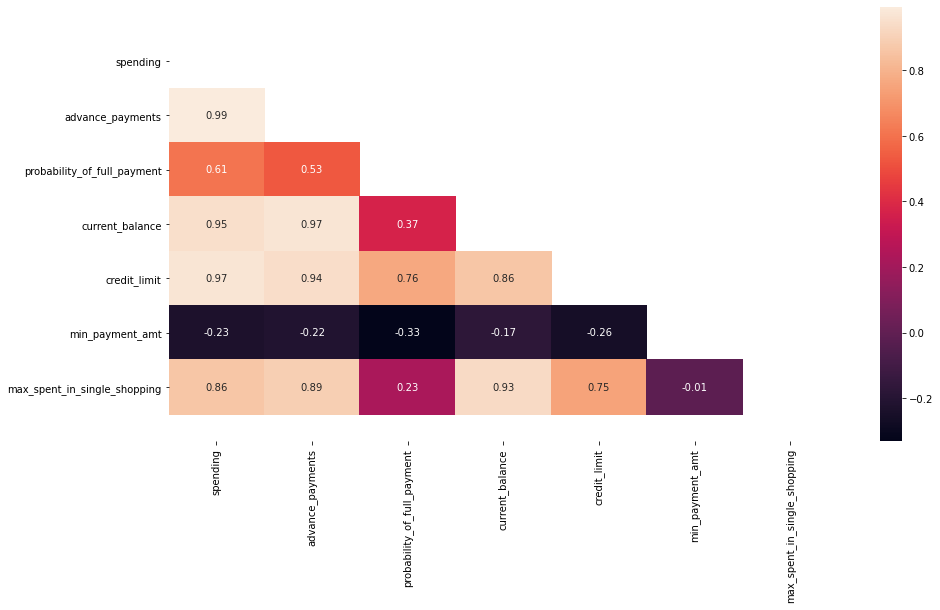

In [10]:
mask = np.triu(np.ones_like(corr, dtype=np.bool)) 
fig = plt.subplots(figsize=(15, 8))
ax=sns.heatmap(df.corr(), annot=True,fmt='.2f',mask=mask)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.show()

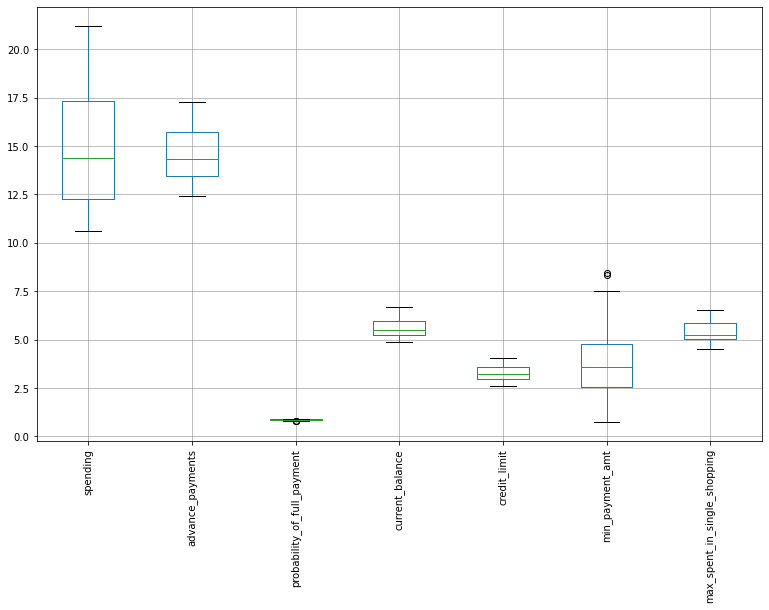

In [11]:
df.boxplot(figsize=(13,8))
plt.xticks(rotation=90)
plt.show()

In [12]:
def treat_outlier(x):
    q5= np.percentile(x,5)
    q25=np.percentile(x,25)
    q75=np.percentile(x,75)
    dt=np.percentile(x,95)
    IQR=q75-q25
    lower_bound=q25-(1.5*IQR)
    upper_bound=q75+(1.5*IQR)
    return x.apply(lambda y: dt if y > upper_bound else y).apply(lambda y: q5 if y < lower_bound else y)

In [13]:
for i in lstnumericcolumns:    
    df[i]=treat_outlier(df[i])

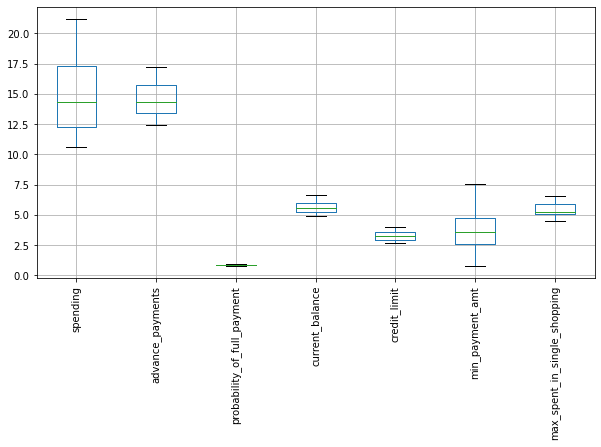

In [14]:
df.boxplot(figsize=(10,5))
plt.xticks(rotation=90)
plt.show()

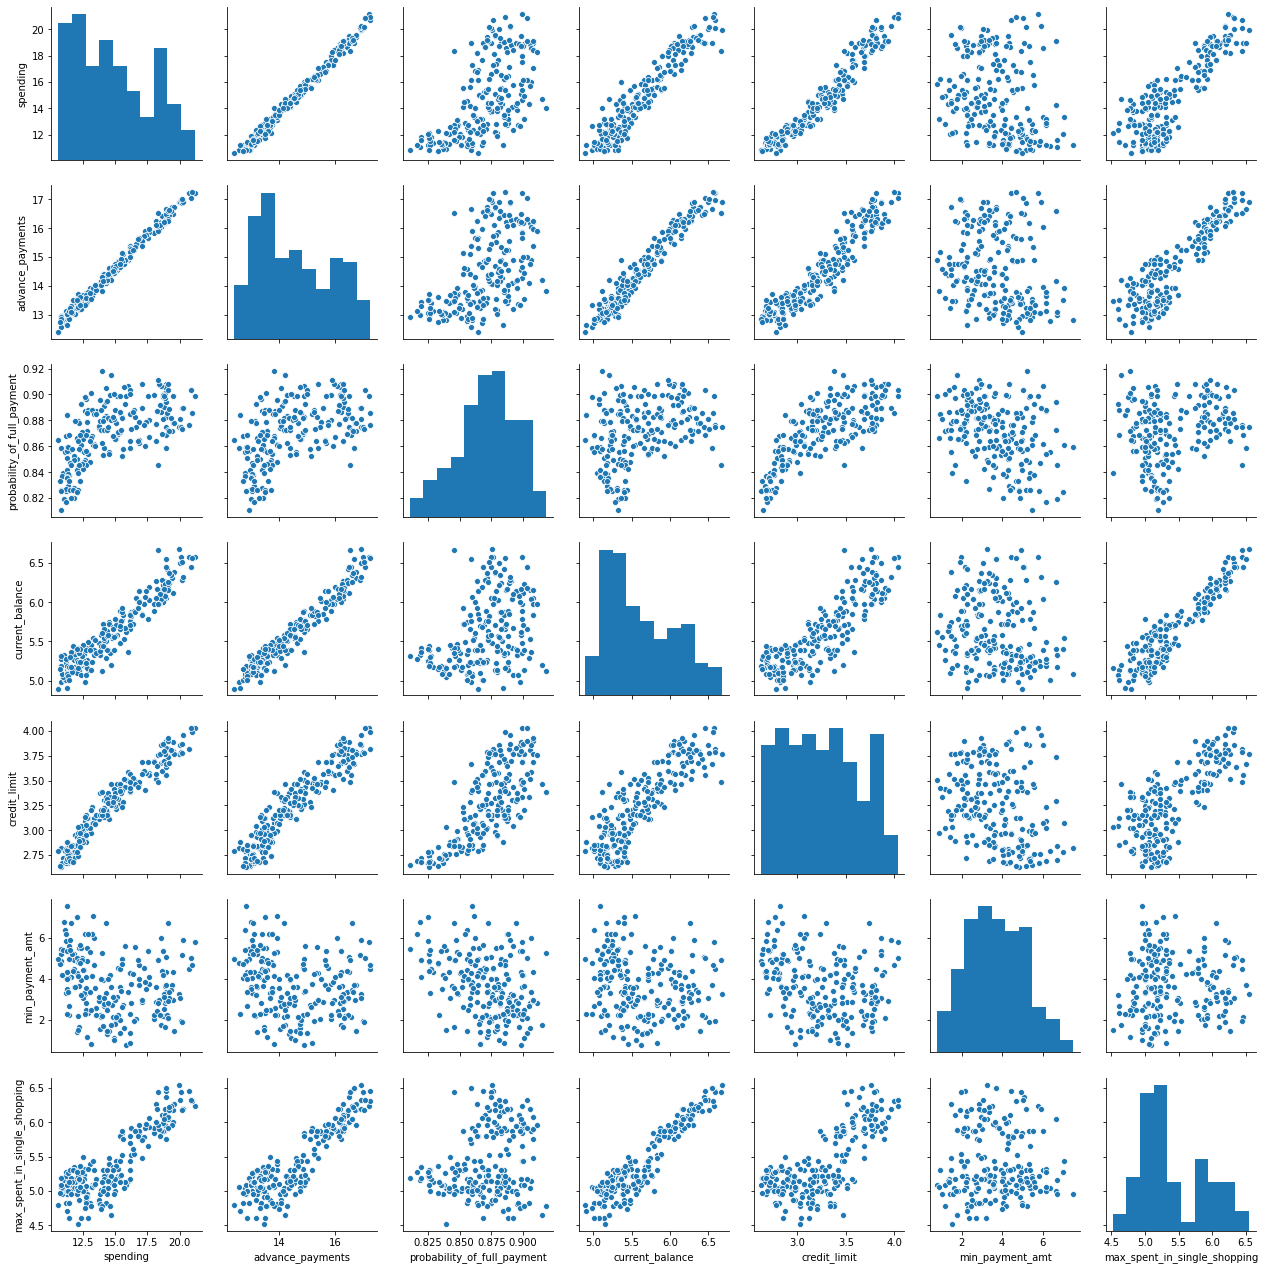

In [15]:
sns.pairplot(df)

In [16]:
from scipy.stats import zscore
df_scaled=df.apply(zscore)
df_scaled.head()

,spending,advance_payments,probability_of_full_payment,current_balance,credit_limit,min_payment_amt,max_spent_in_single_shopping
0,1.754355,1.811968,0.171955,2.367533,1.338579,-0.294861,2.328998
1,0.393582,0.253840,1.528129,-0.600744,0.858236,-0.236880,-0.538582
2,1.413300,1.428192,0.506652,1.401485,1.317348,-0.214791,1.509107
3,-1.384034,-1.227533,-1.970322,-0.793049,-1.639017,1.037338,-0.454961
4,1.082581,0.998364,1.215165,0.591544,1.155464,-1.112128,0.874813


In [17]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [18]:
wardlink = linkage(df_scaled, method = 'ward')

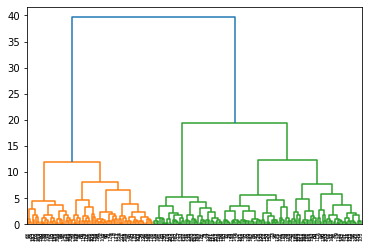

In [19]:
dend = dendrogram(wardlink)

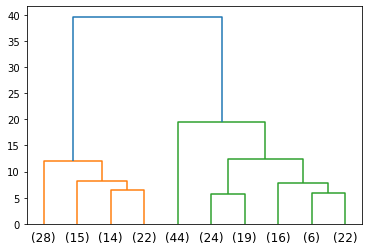

In [20]:
dend = dendrogram(wardlink,truncate_mode='lastp',p = 10)

In [21]:
from scipy.cluster.hierarchy import fcluster

In [22]:
#Method 1

clusters = fcluster(wardlink, 3, criterion='maxclust')
clusters

array([1, 2, 1, 3, 1, 3, 3, 2, 1, 3, 1, 1, 3, 1, 3, 3, 2, 3, 3, 3, 3, 3,
       1, 3, 2, 1, 3, 3, 3, 3, 2, 3, 3, 2, 3, 3, 3, 3, 3, 1, 1, 2, 1, 1,
       3, 3, 3, 1, 1, 1, 3, 1, 1, 1, 1, 1, 3, 3, 3, 1, 2, 3, 3, 1, 2, 1,
       1, 2, 1, 3, 2, 3, 1, 1, 3, 1, 2, 3, 1, 2, 2, 3, 2, 1, 3, 1, 1, 1,
       1, 3, 3, 1, 2, 3, 3, 1, 1, 1, 3, 1, 3, 1, 2, 1, 2, 1, 1, 3, 3, 1,
       1, 2, 1, 3, 3, 1, 2, 3, 3, 1, 3, 3, 3, 3, 2, 2, 1, 3, 2, 2, 3, 2,
       3, 1, 3, 1, 1, 3, 1, 3, 1, 2, 3, 3, 2, 3, 1, 3, 2, 3, 2, 3, 2, 1,
       3, 2, 2, 3, 2, 1, 1, 3, 1, 1, 1, 3, 1, 2, 3, 3, 2, 3, 2, 1, 1, 1,
       2, 3, 1, 3, 2, 3, 3, 2, 1, 1, 3, 1, 3, 3, 3, 2, 3, 1, 2, 1, 1, 3,
       1, 3, 2, 1, 2, 3, 1, 3, 1, 2, 1, 1], dtype=int32)

In [23]:
# Method 2

clusters = fcluster(wardlink, 16, criterion='distance')
clusters

array([1, 2, 1, 3, 1, 3, 3, 2, 1, 3, 1, 1, 3, 1, 3, 3, 2, 3, 3, 3, 3, 3,
       1, 3, 2, 1, 3, 3, 3, 3, 2, 3, 3, 2, 3, 3, 3, 3, 3, 1, 1, 2, 1, 1,
       3, 3, 3, 1, 1, 1, 3, 1, 1, 1, 1, 1, 3, 3, 3, 1, 2, 3, 3, 1, 2, 1,
       1, 2, 1, 3, 2, 3, 1, 1, 3, 1, 2, 3, 1, 2, 2, 3, 2, 1, 3, 1, 1, 1,
       1, 3, 3, 1, 2, 3, 3, 1, 1, 1, 3, 1, 3, 1, 2, 1, 2, 1, 1, 3, 3, 1,
       1, 2, 1, 3, 3, 1, 2, 3, 3, 1, 3, 3, 3, 3, 2, 2, 1, 3, 2, 2, 3, 2,
       3, 1, 3, 1, 1, 3, 1, 3, 1, 2, 3, 3, 2, 3, 1, 3, 2, 3, 2, 3, 2, 1,
       3, 2, 2, 3, 2, 1, 1, 3, 1, 1, 1, 3, 1, 2, 3, 3, 2, 3, 2, 1, 1, 1,
       2, 3, 1, 3, 2, 3, 3, 2, 1, 1, 3, 1, 3, 3, 3, 2, 3, 1, 2, 1, 1, 3,
       1, 3, 2, 1, 2, 3, 1, 3, 1, 2, 1, 1], dtype=int32)

In [24]:
df_clusters=df

In [25]:
df_clusters["Clusters"]=clusters

In [26]:
df_clusters.head()

,spending,advance_payments,probability_of_full_payment,current_balance,credit_limit,min_payment_amt,max_spent_in_single_shopping,Clusters
0,19.94,16.92,0.875200,6.675,3.763,3.252,6.550,1
1,15.99,14.89,0.906400,5.363,3.582,3.336,5.144,2
2,18.95,16.42,0.882900,6.248,3.755,3.368,6.148,1
3,10.83,12.96,0.825915,5.278,2.641,5.182,5.185,3
4,17.99,15.86,0.899200,5.890,3.694,2.068,5.837,1


In [27]:
dfgroup=df_clusters.groupby("Clusters")

In [28]:
dfmean=dfgroup.mean()

In [29]:
dfmean

,spending,advance_payments,probability_of_full_payment,current_balance,credit_limit,min_payment_amt,max_spent_in_single_shopping
Clusters,,,,,,,
1,18.039367,16.011266,0.882377,6.117468,3.641975,3.627253,5.957266
2,14.582955,14.407045,0.882357,5.535318,3.283818,2.316775,5.109841
3,12.082989,13.317816,0.855514,5.231701,2.897736,4.415353,5.060207


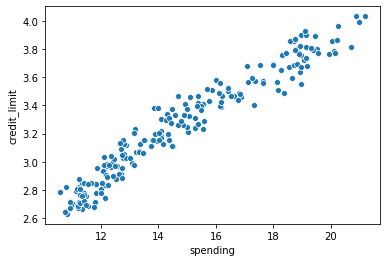

In [30]:
sns.scatterplot(df_clusters["spending"],df_clusters["credit_limit"])

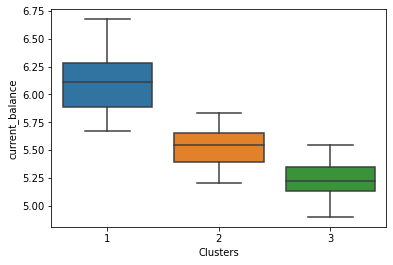

In [31]:
sns.boxplot(df_clusters["Clusters"],df_clusters["current_balance"])

(array([0, 1, 2]), <a list of 3 Text major ticklabel objects>)

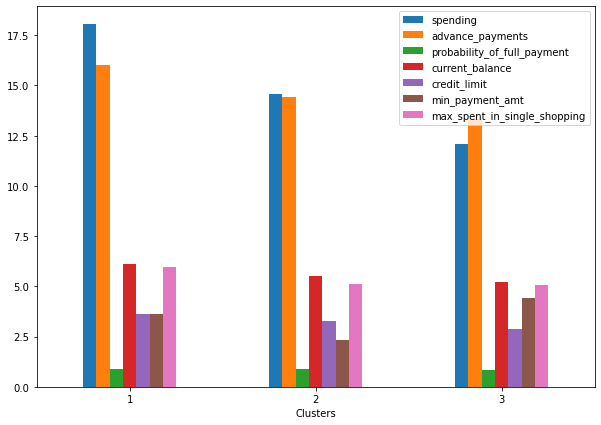

In [34]:
dfmean.plot.bar(figsize=(10,7))
plt.xticks(rotation=360)

In [35]:
from sklearn.cluster import KMeans 

In [36]:
k_means = KMeans(n_clusters = 3)

In [37]:
k_means.fit(df_scaled)

KMeans(n_clusters=3)

In [38]:
k_means.labels_

array([0, 2, 0, 1, 0, 1, 1, 2, 0, 1, 0, 2, 1, 0, 2, 1, 2, 1, 1, 1, 1, 1,
       0, 1, 2, 0, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0,
       1, 1, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 2, 1, 1, 2, 2, 0,
       0, 2, 0, 1, 2, 1, 0, 0, 1, 0, 2, 1, 0, 2, 2, 2, 2, 0, 1, 2, 0, 0,
       0, 1, 2, 0, 2, 1, 1, 0, 0, 0, 1, 0, 2, 0, 2, 0, 2, 0, 0, 1, 1, 0,
       2, 2, 0, 1, 1, 0, 2, 2, 1, 0, 2, 1, 1, 1, 2, 2, 0, 1, 2, 2, 1, 2,
       2, 0, 1, 0, 0, 1, 0, 2, 2, 2, 1, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 2,
       1, 2, 2, 1, 2, 0, 0, 1, 0, 0, 0, 1, 2, 2, 2, 1, 2, 1, 2, 0, 0, 0,
       2, 1, 2, 1, 2, 2, 2, 2, 0, 0, 1, 2, 2, 1, 2, 2, 1, 0, 2, 0, 0, 1,
       0, 1, 2, 0, 2, 1, 0, 2, 0, 2, 2, 2])

In [39]:
k_means.inertia_

429.41517904599925

In [40]:
df_kmeans=df

In [41]:
k_means = KMeans(n_clusters = 1)
k_means.fit(df_scaled)
k_means.inertia_

1469.9999999999995

In [42]:
k_means = KMeans(n_clusters = 2)
k_means.fit(df_scaled)
k_means.inertia_

659.1308122335325

In [43]:
k_means = KMeans(n_clusters = 3)
k_means.fit(df_scaled)
k_means.inertia_

429.41517904599925

In [45]:
k_means = KMeans(n_clusters = 4)
k_means.fit(df_scaled)
k_means.inertia_

370.23767904201367

In [46]:
k_means = KMeans(n_clusters = 5)
k_means.fit(df_scaled)
k_means.inertia_

322.1752568424512

In [47]:
k_means = KMeans(n_clusters = 6)
k_means.fit(df_scaled)
k_means.inertia_

290.5970490183782

In [48]:
wss =[]
for i in range(1,11):
    KM = KMeans(n_clusters=i)
    KM.fit(df_scaled)
    wss.append(KM.inertia_)

In [49]:
wss

[1469.9999999999995,
 659.1308122335325,
 429.4139632109117,
 369.43996994813534,
 322.1970030959652,
 290.7576873811963,
 264.05084148422793,
 241.58506518738258,
 224.80962969151105,
 204.91954916433937]

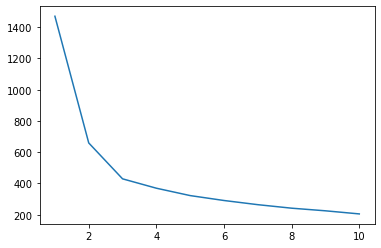

In [50]:
plt.plot(range(1,11), wss)

In [51]:
k_means = KMeans(n_clusters = 3)
k_means.fit(df_scaled)
labels = k_means.labels_

In [52]:
df_kmeans=df
df_kmeans["Clus_kmeans"] = labels
df_kmeans.head(5)

,spending,advance_payments,probability_of_full_payment,current_balance,credit_limit,min_payment_amt,max_spent_in_single_shopping,Clusters,Clus_kmeans
0,19.94,16.92,0.875200,6.675,3.763,3.252,6.550,1,1
1,15.99,14.89,0.906400,5.363,3.582,3.336,5.144,2,2
2,18.95,16.42,0.882900,6.248,3.755,3.368,6.148,1,1
3,10.83,12.96,0.825915,5.278,2.641,5.182,5.185,3,0
4,17.99,15.86,0.899200,5.890,3.694,2.068,5.837,1,1


In [53]:
from sklearn.metrics import silhouette_samples, silhouette_score

In [54]:
silhouette_score(df_scaled,labels)

0.4021931705839431

In [55]:
df_kcluster=df_kmeans.drop("Clusters",axis=1)

In [57]:
df_kgroup=df_kcluster.groupby("Clus_kmeans")
df_kgmean=df_kgroup.mean()
df_kgmean

,spending,advance_payments,probability_of_full_payment,current_balance,credit_limit,min_payment_amt,max_spent_in_single_shopping
Clus_kmeans,,,,,,,
0,11.865775,13.256479,0.848475,5.236394,2.849127,4.715037,5.107338
1,18.495373,16.203433,0.884210,6.175687,3.697537,3.632373,6.041701
2,14.393333,14.314028,0.881631,5.506069,3.253944,2.701253,5.115000


(array([0, 1, 2]), <a list of 3 Text major ticklabel objects>)

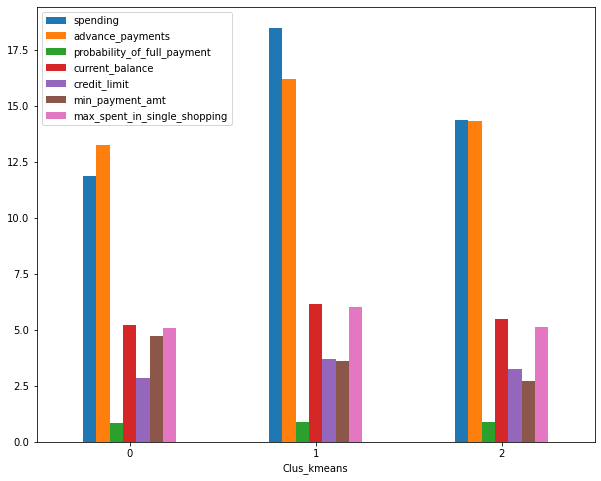

In [60]:
df_kgmean.plot.bar(figsize=(10,8))
plt.xticks(rotation=360)